In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\Data\semantic_data.csv")

In [3]:
df.head()

,question,documents,response,label,doc_response_similarity,question_response_similarity,question_document_similarity,question_embeddings,document_embeddings,response_embeddings
0,In what school district is Governor John R. Ro...,['Governor John R. Rogers High School is a hig...,"Governor John R. Rogers High School, named aft...",GROUNDED,0.734998,0.923933,0.710141,[-8.29930902e-02 7.60140121e-02 1.15349991e-...,[-5.79451062e-02 -1.82107009e-03 6.14077337e-...,[-8.34821835e-02 7.63497353e-02 2.06497309e-...
1,whiich Australian racing driver won the 44-lap...,"['Colin Fleming (born April 21, 1984 in San Di...",Daniel Ricciardo won the 44-lap race for the R...,GROUNDED,0.504248,0.743390,0.466463,[ 2.58376785e-02 4.59632166e-02 -7.01652318e-...,[-5.22545464e-02 -9.30328816e-02 -6.02295026e-...,[ 3.63201872e-02 1.64219011e-02 -5.93438633e-...
2,What star of Parks and Recreation appeared in ...,['Pioneer Park is a 44-acre (109-ha) city park...,"Nick Offerman, who played the role of Ron Swan...",GROUNDED,0.245878,0.616227,0.371195,[ 3.54567985e-03 -6.40575821e-03 -1.75953703e-...,[ 3.22299963e-03 -3.81004810e-02 2.71010343e-...,[-1.05648018e-01 -6.89102188e-02 -1.47342058e-...
3,Which genus of flowering plant is found in an ...,['Actaea arizonica is a species of flowering p...,Crocosmia is found in an environment further s...,GROUNDED,0.462568,0.617127,0.690663,[ 1.22428481e-02 2.27324683e-02 -5.80804460e-...,[ 1.73412878e-02 -2.90998165e-02 -1.32692516e-...,[ 7.98351765e-02 -6.27395418e-03 -4.21682857e-...
4,In what year did the man who shot the Chris St...,['Dennis Bruce Allen (7 November 1951 – 13 Apr...,"Dennis Bruce Allen, the man who shot Chris Sto...",GROUNDED,0.485141,0.804504,0.409791,[ 9.22157895e-03 6.32653683e-02 -9.36103612e-...,[ 2.39467956e-02 -7.25752413e-02 -8.11747462e-...,[ 2.90469010e-03 6.63615018e-02 -1.12968549e-...


In [4]:
df.columns

Index(['question', 'documents', 'response', 'label', 'doc_response_similarity',
       'question_response_similarity', 'question_document_similarity',
       'question_embeddings', 'document_embeddings', 'response_embeddings'],
      dtype='str')

In [28]:
X=df.drop(["question","documents","response","label"],axis=1)
y=df["label"]

In [29]:
import numpy as np

X_embedding = df[["question_embeddings", "document_embeddings", "response_embeddings"]].map(
    lambda x: np.fromstring(x.strip("[]"), sep=" ")
)

In [30]:
X=pd.concat([X_embedding,X[["question_response_similarity","question_document_similarity","doc_response_similarity"]]],axis=1)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,stratify=y)

In [32]:
from imblearn.over_sampling import SMOTE

In [33]:
X_train = np.hstack([
    np.vstack(X_train["question_embeddings"]),
    np.vstack(X_train["document_embeddings"]),
    np.vstack(X_train["response_embeddings"])
])

X_test = np.hstack([
    np.vstack(X_test["question_embeddings"]),
    np.vstack(X_test["document_embeddings"]),
    np.vstack(X_test["response_embeddings"])
])

print(X_train.shape)

(1506, 1152)


In [34]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [35]:
print("Before:")
print(y_train.value_counts())

print("\nAfter:")
print(pd.Series(y_train_smote).value_counts())

Before:
label
GROUNDED              1379
HALLUCINATED           112
PARTIALLY_GROUNDED      15
Name: count, dtype: int64

After:
label
GROUNDED              1379
HALLUCINATED          1379
PARTIALLY_GROUNDED    1379
Name: count, dtype: int64


In [36]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay
)

Accuracy: 0.8063660477453581
Macro F1: 0.34890868971586464
                    precision    recall  f1-score   support

          GROUNDED       0.92      0.86      0.89       345
      HALLUCINATED       0.12      0.21      0.16        28
PARTIALLY_GROUNDED       0.00      0.00      0.00         4

          accuracy                           0.81       377
         macro avg       0.35      0.36      0.35       377
      weighted avg       0.85      0.81      0.83       377



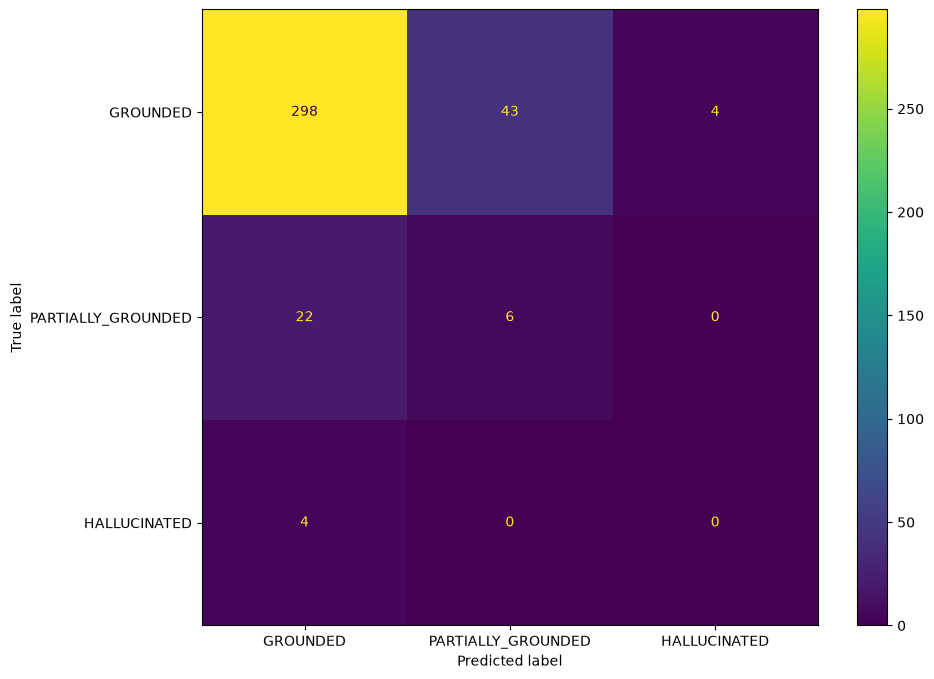

In [37]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()

In [38]:
from sklearn.svm import LinearSVC

Accuracy: 0.8275862068965517
Macro F1: 0.365161508540504
                    precision    recall  f1-score   support

          GROUNDED       0.92      0.88      0.90       345
      HALLUCINATED       0.16      0.25      0.19        28
PARTIALLY_GROUNDED       0.00      0.00      0.00         4

          accuracy                           0.83       377
         macro avg       0.36      0.38      0.37       377
      weighted avg       0.86      0.83      0.84       377



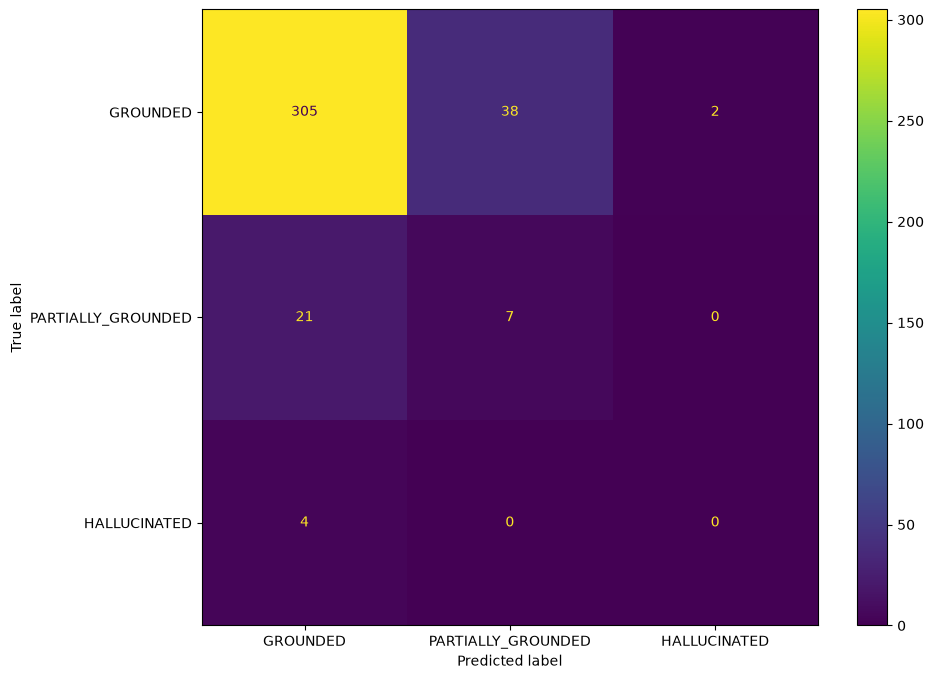

In [39]:
svm_model = LinearSVC(
    class_weight="balanced"
)

svm_model.fit(X_train_smote, y_train_smote)

svm_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, svm_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        svm_pred,
        average="macro"
    )
)

print(classification_report(y_test, svm_pred))

cm = confusion_matrix(y_test, svm_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()

Accuracy: 0.9151193633952255
Macro F1: 0.3185595567867036
                    precision    recall  f1-score   support

          GROUNDED       0.92      1.00      0.96       345
      HALLUCINATED       0.00      0.00      0.00        28
PARTIALLY_GROUNDED       0.00      0.00      0.00         4

          accuracy                           0.92       377
         macro avg       0.31      0.33      0.32       377
      weighted avg       0.84      0.92      0.87       377



c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

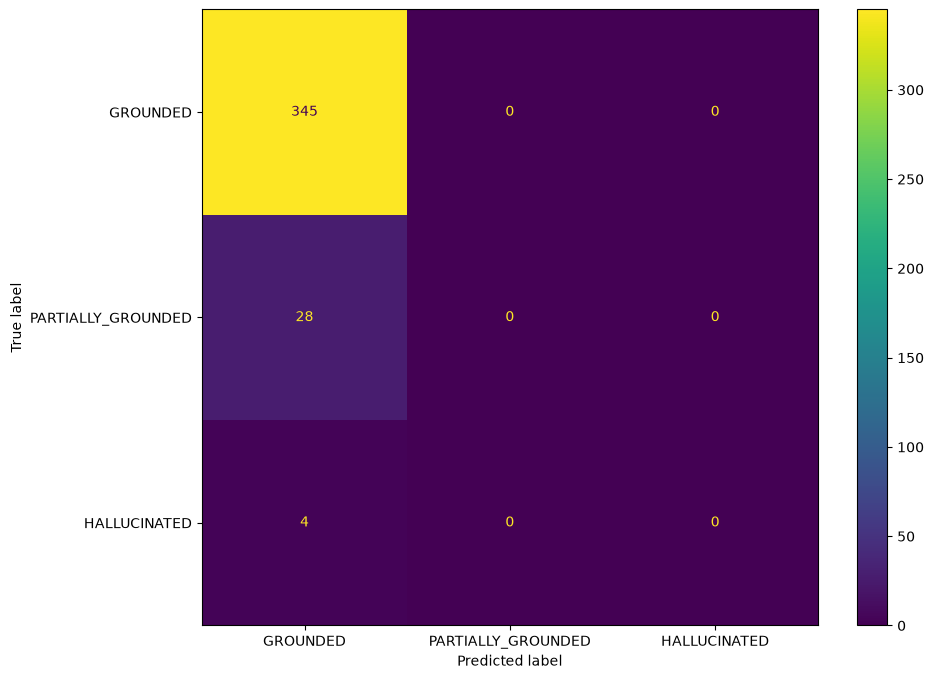

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        rf_pred,
        average="macro"
    )
)

print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()


In [41]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,stratify=y)

In [43]:
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [44]:
X_train = np.hstack([
    np.vstack(X_train["question_embeddings"]),
    np.vstack(X_train["document_embeddings"]),
    np.vstack(X_train["response_embeddings"])
])

X_test = np.hstack([
    np.vstack(X_test["question_embeddings"]),
    np.vstack(X_test["document_embeddings"]),
    np.vstack(X_test["response_embeddings"])
])

print(X_train.shape)

(1506, 1152)


In [45]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train_encoded
)

Accuracy: 0.9151193633952255
Macro F1: 0.3185595567867036
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       345
           1       0.00      0.00      0.00        28
           2       0.00      0.00      0.00         4

    accuracy                           0.92       377
   macro avg       0.31      0.33      0.32       377
weighted avg       0.84      0.92      0.87       377



c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

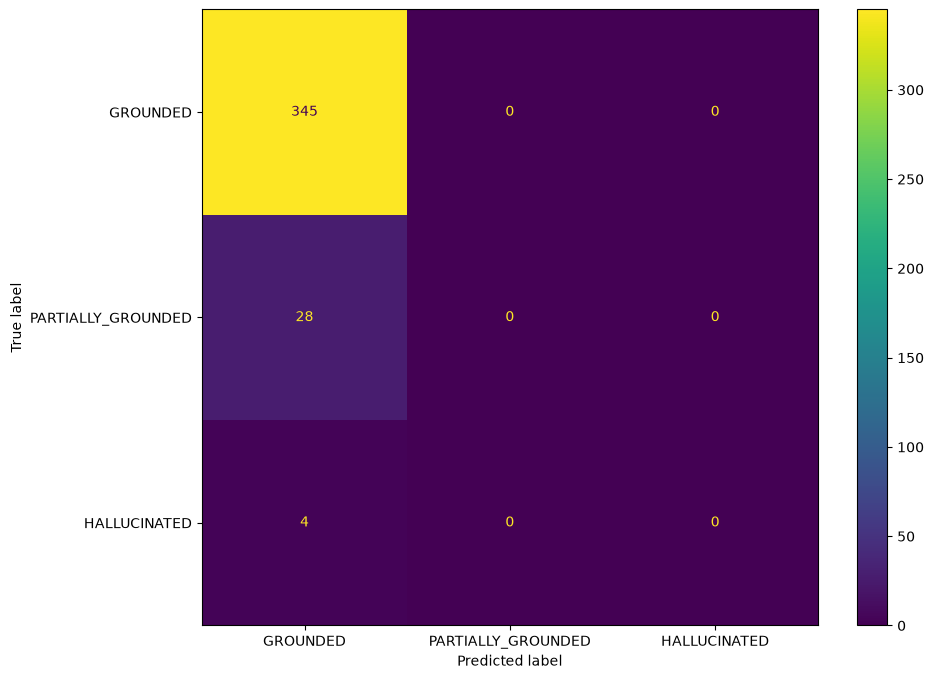

In [46]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

xgb_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test_encoded, xgb_pred))

print(
    "Macro F1:",
    f1_score(
        y_test_encoded,
        xgb_pred,
        average="macro"
    )
)

print(classification_report(y_test_encoded, xgb_pred))

cm = confusion_matrix(y_test_encoded, xgb_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()